# Mobile wallet in store vs card payments online

**Business question:** a large share of active cards never pay online. Does behaviour in physical stores,
especially paying with a phone (Apple Pay / Google Pay), tell us who is ready to start, what their first
online purchase looks like, and what makes them stay?

Research questions:
1. **Gap**: how many active cards never pay online?
2. **Readiness**: are phone-in-store users more likely to pay online, also after controlling for how active the card is?
3. **Sequence**: does starting to pay by phone in store come *before* the first online payment?
4. **Channel**: how do wallet users pay online (saved card / typed card number / in-app)?
5. **Stickiness**: do cards whose first online payment was one-click (card on file) keep paying online more often than those who typed the card number?
6. **Gateway**: what is the first thing people buy online?
7. **Target segment**: how big is the "ready but not converted" group and where does it live?

**Definitions**
- Scope: Polish-issued cards (`issr_ctry_nm = 'POLAND'`), `transaction_type = 'POS'` (ATM excluded).
- *In store* = `cp_flag = 1`. *Wallet in store* = in store and `channel_flg = 'mobile'` (phone / watch tap).
- *Online purchase* = `cp_flag = 0`, excluding money movements (MCC 4829 wire transfers, 6012/6051/6540/6538 financial / top-ups, 6211 brokers), which are not shopping.
- *Active card* = at least 6 active months and 60 transactions.

**Compliance** (challenge rules): every displayed group must contain at least 30 cards; `safe()` drops smaller groups.
Results are grouped by merchant category, never by single merchant.

Data are synthetic: patterns show the method, not real market figures. All relationships are correlations, not proven causes.

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

import readiness as rd
from paths import CACHE, DATA
CACHE.mkdir(exist_ok=True)
SLIM = CACHE / "slim"                   # card-partitioned subset of the columns, 16 buckets
PANEL = CACHE / "card_month_panel"      # one parquet file per bucket
FIRST_ONLINE = CACHE / "card_first_online"
N_BUCKETS = 16
# Online categories that pass the 3/75 rule (>= 3 merchants, none above 75%); see check_3_75.py
OK_CATS = rd.passing_3_75("mcc")

con = duckdb.connect()
con.sql("SET memory_limit = '4GB'")
con.sql(f"SET temp_directory = '{(CACHE / 'duckdb_tmp').as_posix()}'")
con.sql("SET max_temp_directory_size = '1GB'")  # the disk is nearly full
con.sql("SET threads = 4")
con.sql("SET preserve_insertion_order = false")

pd.set_option("display.float_format", "{:,.1f}".format)
plt.rcParams.update({
    "figure.figsize": (11, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})
pct = mtick.PercentFormatter(100)

MIN_CARDS = 30

def safe(df, cards_col="cards"):
    """Drop groups below the anonymity threshold."""
    return df[df[cards_col] >= MIN_CARDS].copy()

NOT_SHOPPING_MCC = "(4829, 6012, 6051, 6211, 6538, 6540)"
BASE_FILTER = "issr_ctry_nm = 'POLAND' AND transaction_type = 'POS'"

## Build the cache (full data, first run only)

Grouping 305M rows by card does not fit in 8 GB RAM in one go, so:
1. `slim/`: one streaming pass copies only the needed columns, split into 16 buckets by card (card id replaced by a 64-bit hash).
2. Each bucket (~120k cards) is aggregated separately into:
   - `card_month_panel/`: one row per card and month with counts of in-store, wallet-in-store and online transactions;
   - `card_first_online/`: card type, home area and the category, entry mode and channel of each card's first online purchase.

`slim/` is also handy for further card-level analyses: it is much faster to query than the original file.

In [2]:
if not SLIM.exists():
    con.sql(f'''
        COPY (
            SELECT hash(pymt_crd_acct_num_raw) AS card,
                   hash(pymt_crd_acct_num_raw) % {N_BUCKETS} AS bucket,
                   prch_mnth_id::INTEGER AS month,
                   CAST(replace(prch_dt, '-', '') AS BIGINT) * 1000000 + CAST(tran_id_gmt_tm AS BIGINT) AS ts,
                   cp_flag::TINYINT AS cp_flag, channel_flg, transaction_pos_entry_mode AS entry_mode,
                   mrch_catg_cd, mrch_catg_nm, mrch_ctry_nm = 'POLAND' AS merchant_pl,
                   crd_typ_nm AS card_type, fua_enr AS home_fua,
                   CAST(cs_tran_amt AS DOUBLE) AS amt
            FROM '{DATA}'
            WHERE {BASE_FILTER}
        ) TO '{SLIM.as_posix()}' (FORMAT parquet, PARTITION_BY (bucket))
    ''')

IS_ONLINE = f"(cp_flag = 0 AND mrch_catg_cd NOT IN {NOT_SHOPPING_MCC})"

for out in (PANEL, FIRST_ONLINE):
    out.mkdir(exist_ok=True)

for b in range(N_BUCKETS):
    src = f"'{SLIM.as_posix()}/bucket={b}/*.parquet'"
    panel_file = PANEL / f"{b:02d}.parquet"
    first_file = FIRST_ONLINE / f"{b:02d}.parquet"
    if not panel_file.exists():
        con.sql(f'''
            COPY (
                SELECT card, month,
                       count(*) AS n_tx,
                       count(*) FILTER (WHERE cp_flag = 1) AS n_store,
                       count(*) FILTER (WHERE cp_flag = 1 AND channel_flg = 'mobile') AS n_wallet_store,
                       count(*) FILTER (WHERE {IS_ONLINE}) AS n_online,
                       count(*) FILTER (WHERE {IS_ONLINE} AND entry_mode = 'COF') AS n_online_cof,
                       count(*) FILTER (WHERE {IS_ONLINE} AND entry_mode = 'Manual key entry') AS n_online_manual,
                       count(*) FILTER (WHERE {IS_ONLINE} AND channel_flg = 'mobile') AS n_online_mobile
                FROM read_parquet({src})
                GROUP BY 1, 2
            ) TO '{panel_file.as_posix()}' (FORMAT parquet)
        ''')
    if not first_file.exists():
        con.sql(f'''
            COPY (
                SELECT card,
                       any_value(card_type) AS card_type,
                       any_value(home_fua) AS home_fua,
                       min(ts) FILTER (WHERE {IS_ONLINE}) AS first_ts,
                       arg_min(mrch_catg_nm, ts) FILTER (WHERE {IS_ONLINE}) AS first_cat,
                       arg_min(entry_mode, ts) FILTER (WHERE {IS_ONLINE}) AS first_mode,
                       arg_min(channel_flg, ts) FILTER (WHERE {IS_ONLINE}) AS first_channel,
                       arg_min(merchant_pl, ts) FILTER (WHERE {IS_ONLINE}) AS first_domestic
                FROM read_parquet({src})
                GROUP BY 1
            ) TO '{first_file.as_posix()}' (FORMAT parquet)
        ''')
    print(f"bucket {b} done")

bucket 0 done
bucket 1 done
bucket 2 done
bucket 3 done
bucket 4 done
bucket 5 done
bucket 6 done
bucket 7 done
bucket 8 done
bucket 9 done
bucket 10 done
bucket 11 done
bucket 12 done
bucket 13 done
bucket 14 done
bucket 15 done


In [3]:
# Month index for arithmetic (Jan 2025 = 0)
con.sql(f'''
    CREATE OR REPLACE VIEW panel AS
    SELECT *, (month // 100 - 2025) * 12 + month % 100 - 1 AS m
    FROM read_parquet('{PANEL.as_posix()}/*.parquet')
''')
con.sql(f"CREATE OR REPLACE VIEW first_online AS SELECT * FROM read_parquet('{FIRST_ONLINE.as_posix()}/*.parquet')")

con.sql('''
    CREATE OR REPLACE TABLE cards AS
    SELECT card,
           any_value(f.card_type) AS card_type,
           any_value(f.home_fua) AS home_fua,
           count(*) AS months_active,
           min(m) AS first_m,
           sum(n_tx) AS n_tx,
           sum(n_store) AS n_store,
           sum(n_wallet_store) AS n_wallet_store,
           sum(n_online) AS n_online,
           sum(n_online_cof) AS n_online_cof,
           sum(n_online_manual) AS n_online_manual,
           sum(n_online_mobile) AS n_online_mobile,
           min(m) FILTER (WHERE n_online > 0) AS first_online_m,
           min(m) FILTER (WHERE n_wallet_store > 0) AS first_wallet_m,
           count(*) FILTER (WHERE m <= 2) AS early_months
    FROM panel JOIN first_online f USING (card)
    GROUP BY card
''')

# Active cards with an activity quintile (transactions per active month) used as a control
con.sql('''
    CREATE OR REPLACE TABLE active AS
    SELECT *,
           n_wallet_store / nullif(n_store, 0) AS wallet_share,
           ntile(5) OVER (ORDER BY n_tx / months_active) AS activity_q
    FROM cards
    WHERE months_active >= 6 AND n_tx >= 60
''')
con.sql("SELECT count(*) AS all_cards, (SELECT count(*) FROM active) AS active_cards FROM cards").df()

,all_cards,active_cards
0,1306809,759147


## 1. Gap: how many active cards never pay online?

In [4]:
gap = con.sql('''
    SELECT CASE WHEN n_online = 0 THEN '1 never'
                WHEN n_online < 12 THEN '2 occasional (1-11)'
                ELSE '3 regular (12+)' END AS segment,
           count(*) AS cards,
           median(n_tx) AS median_tx,
           100 * median(wallet_share) AS median_wallet_share_pct
    FROM active GROUP BY 1 ORDER BY 1
''').df()
gap["share_pct"] = gap.cards / gap.cards.sum() * 100
gap

,segment,cards,median_tx,median_wallet_share_pct,share_pct
0,1 never,274966,220.0,0.0,36.2
1,2 occasional (1-11),161120,220.0,0.0,21.2
2,3 regular (12+),323061,345.0,87.8,42.6


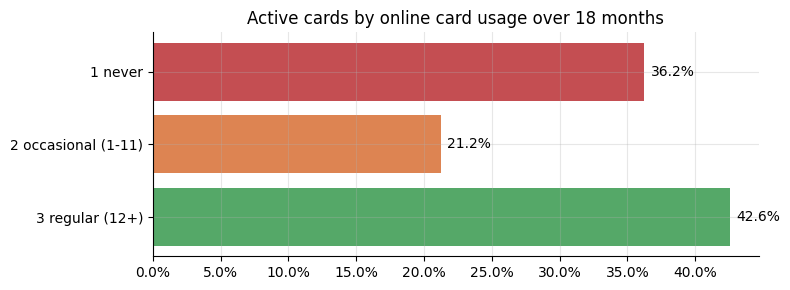

In [5]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(gap.segment, gap.share_pct, color=["#c44e52", "#dd8452", "#55a868"])
ax.xaxis.set_major_formatter(pct)
ax.invert_yaxis()
ax.set_title("Active cards by online card usage over 18 months")
for y, v in enumerate(gap.share_pct):
    ax.text(v + 0.5, y, f"{v:.1f}%", va="center")
plt.tight_layout()

## 2. Readiness: wallet in store vs online adoption

Heavier users do everything more often, so the comparison is made **within activity quintiles**
(Q1 = least transactions per month, Q5 = most). If the wallet line stays above within every quintile,
the link is not just "more active cards".

wallet_group,0 no wallet,1 some wallet (<50%),2 mostly wallet (50%+)
activity_q,,,
1,41.1,75.4,84.7
2,42.4,78.1,87.1
3,45.7,79.5,90.3
4,49.7,81.9,93.0
5,54.4,85.8,95.9


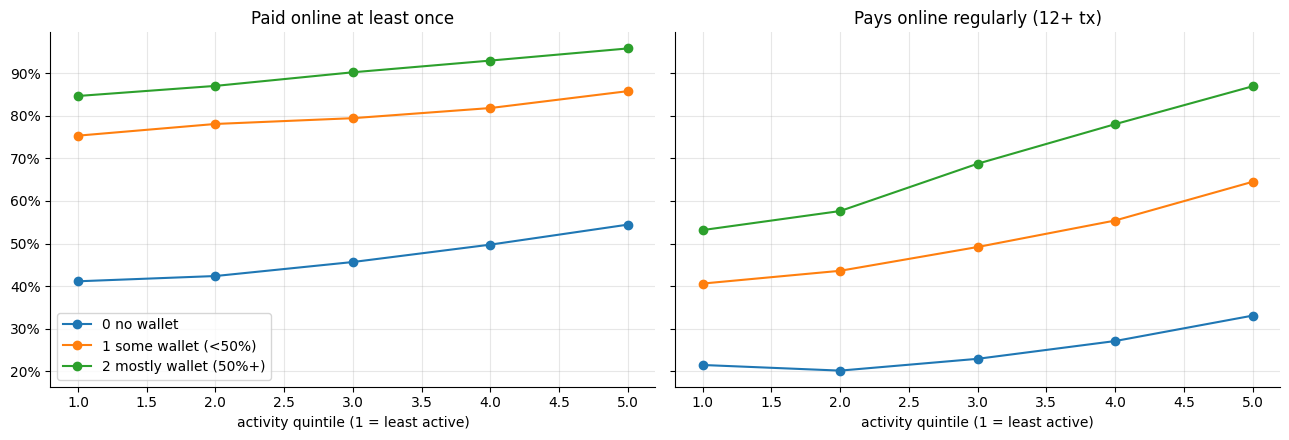

In [6]:
ready = safe(con.sql('''
    SELECT activity_q,
           CASE WHEN n_wallet_store = 0 THEN '0 no wallet'
                WHEN wallet_share < 0.5 THEN '1 some wallet (<50%)'
                ELSE '2 mostly wallet (50%+)' END AS wallet_group,
           count(*) AS cards,
           100 * avg((n_online > 0)::INT) AS any_online_pct,
           100 * avg((n_online >= 12)::INT) AS regular_online_pct
    FROM active GROUP BY ALL ORDER BY ALL
''').df())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, col, title in zip(axes, ["any_online_pct", "regular_online_pct"],
                          ["Paid online at least once", "Pays online regularly (12+ tx)"]):
    for grp, d in ready.groupby("wallet_group"):
        ax.plot(d.activity_q, d[col], marker="o", label=grp)
    ax.set_title(title)
    ax.set_xlabel("activity quintile (1 = least active)")
    ax.yaxis.set_major_formatter(pct)
axes[0].legend()
plt.tight_layout()
ready.pivot(index="activity_q", columns="wallet_group", values="any_online_pct")

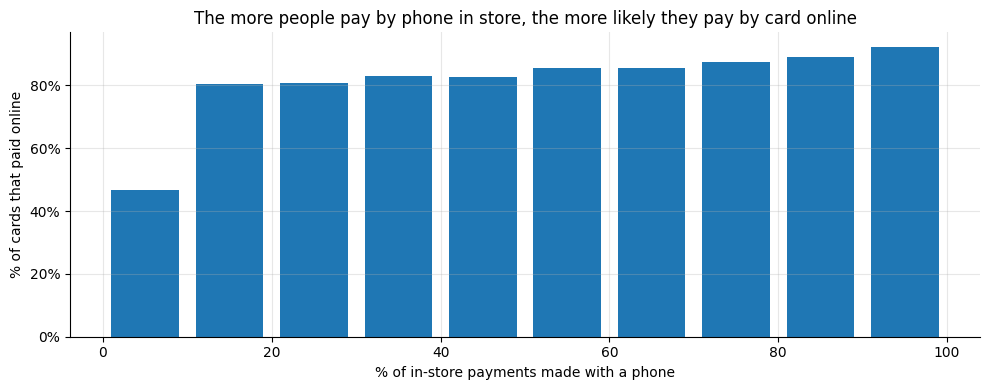

In [7]:
# Finer view: online adoption vs share of in-store payments made by phone
bins = safe(con.sql('''
    SELECT least(floor(wallet_share * 10), 9) * 10 AS wallet_share_bin,
           count(*) AS cards,
           100 * avg((n_online > 0)::INT) AS any_online_pct,
           median(n_online) AS median_online_tx
    FROM active WHERE n_store > 0 GROUP BY 1 ORDER BY 1
''').df())

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(bins.wallet_share_bin + 5, bins.any_online_pct, width=8)
ax.set_xlabel("% of in-store payments made with a phone")
ax.set_ylabel("% of cards that paid online")
ax.yaxis.set_major_formatter(pct)
ax.set_title("The more people pay by phone in store, the more likely they pay by card online")
plt.tight_layout()

## 3. Sequence: does the phone in store come first?

Cohort of cards active since January 2025 with **no online purchase in Jan-Mar 2025**.
From April 2025 we follow them month by month until their first online purchase and compare the monthly
probability of starting (*hazard*) for cards that had already paid by phone in store vs those that had not.

,no wallet yet,already uses wallet,ratio
activity_q,,,
1,1.5,6.0,4.2
2,1.6,6.6,4.2
3,1.7,6.9,4.1
4,1.9,7.0,3.7
5,2.0,6.9,3.5


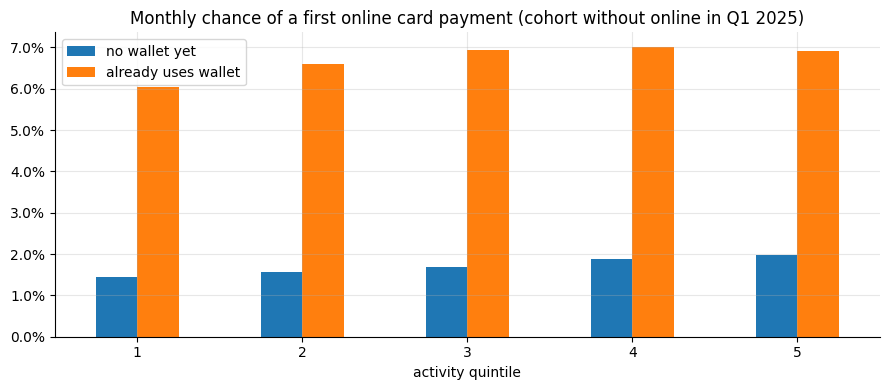

In [8]:
con.sql('''
    CREATE OR REPLACE TABLE cohort AS
    SELECT * FROM cards
    WHERE early_months = 3
      AND (first_online_m IS NULL OR first_online_m >= 3)
''')

hazard = safe(con.sql('''
    WITH risk AS (
        SELECT p.card, p.m, c.first_online_m,
               coalesce(c.first_wallet_m < p.m, FALSE) AS wallet_before,
               ntile(5) OVER (ORDER BY c.n_tx / c.months_active) AS activity_q
        FROM panel p JOIN cohort c USING (card)
        WHERE p.m >= 3 AND (c.first_online_m IS NULL OR p.m <= c.first_online_m)
    )
    SELECT activity_q, wallet_before,
           count(DISTINCT card) AS cards,
           count(*) AS card_months,
           100 * avg(coalesce(m = first_online_m, FALSE)::INT) AS monthly_start_pct
    FROM risk GROUP BY ALL ORDER BY ALL
''').df())

h = hazard.pivot(index="activity_q", columns="wallet_before", values="monthly_start_pct")
h.columns = ["no wallet yet", "already uses wallet"]
h["ratio"] = h["already uses wallet"] / h["no wallet yet"]
ax = h[["no wallet yet", "already uses wallet"]].plot.bar(figsize=(9, 4), rot=0)
ax.set_title("Monthly chance of a first online card payment (cohort without online in Q1 2025)")
ax.set_xlabel("activity quintile")
ax.yaxis.set_major_formatter(pct)
plt.tight_layout()
h

In [9]:
# Among cohort cards that started BOTH during the window: which came first?
seq = con.sql('''
    SELECT CASE WHEN first_wallet_m < first_online_m THEN '1 wallet first'
                WHEN first_wallet_m = first_online_m THEN '2 same month'
                ELSE '3 online first' END AS order_,
           count(*) AS cards
    FROM cohort
    WHERE first_online_m IS NOT NULL AND first_wallet_m >= 3
    GROUP BY 1 ORDER BY 1
''').df()
seq["share_pct"] = seq.cards / seq.cards.sum() * 100
safe(seq)

,order_,cards,share_pct
0,1 wallet first,3289,38.1
1,2 same month,1329,15.4
2,3 online first,4010,46.5


In [10]:
# Event view: after a card starts paying by phone in store, how many start online within 3 months,
# compared with never-wallet cards observed over the same calendar months?
event = con.sql('''
    WITH starts AS (
        SELECT DISTINCT first_wallet_m AS m0 FROM cohort WHERE first_wallet_m BETWEEN 3 AND 14  -- m0 + 3 <= 17 (Jun 2026)
    ),
    new_wallet AS (
        SELECT c.first_wallet_m AS m0,
               count(*) AS cards,
               avg(coalesce(c.first_online_m BETWEEN c.first_wallet_m + 1 AND c.first_wallet_m + 3, FALSE)::INT) AS rate
        FROM cohort c
        WHERE c.first_wallet_m BETWEEN 3 AND 14
          AND (c.first_online_m IS NULL OR c.first_online_m > c.first_wallet_m)
        GROUP BY 1
    ),
    never_wallet AS (
        SELECT s.m0,
               count(*) AS cards,
               avg(coalesce(c.first_online_m BETWEEN s.m0 + 1 AND s.m0 + 3, FALSE)::INT) AS rate
        FROM starts s JOIN cohort c
          ON c.first_wallet_m IS NULL AND (c.first_online_m IS NULL OR c.first_online_m > s.m0)
        GROUP BY 1
    )
    SELECT n.m0, n.cards AS wallet_cards, 100 * n.rate AS wallet_rate_pct,
           b.cards AS never_wallet_cards, 100 * b.rate AS never_wallet_rate_pct
    FROM new_wallet n JOIN never_wallet b USING (m0) ORDER BY m0
''').df()
event = event[event.wallet_cards >= MIN_CARDS]
w = event.wallet_cards
print(f"started online within 3 months after first phone payment: "
      f"{(event.wallet_rate_pct * w).sum() / w.sum():.1f}%  vs never-wallet cards in the same months: "
      f"{(event.never_wallet_rate_pct * w).sum() / w.sum():.1f}%")
event

started online within 3 months after first phone payment: 18.8%  vs never-wallet cards in the same months: 4.0%


,m0,wallet_cards,wallet_rate_pct,never_wallet_cards,never_wallet_rate_pct
0,3,1181,24.0,275546,5.8
1,4,1021,22.3,269470,5.3
2,5,954,20.8,264363,4.8
3,6,950,20.9,259591,4.2
4,7,864,16.8,255207,3.8
5,8,728,18.1,251780,3.6
6,9,599,17.7,248658,3.4
7,10,543,16.4,245534,3.1
8,11,580,14.5,242736,2.8
9,12,541,16.1,240217,2.6


## 4. Channel: how do wallet users pay online?

,wallet_group,cards,saved_card_pct,typed_number_pct,via_phone_pct
0,0 no wallet,205441,81.3,18.7,52.2
1,1 some wallet,38941,70.3,29.7,61.0
2,2 mostly wallet,239799,45.0,55.0,79.8


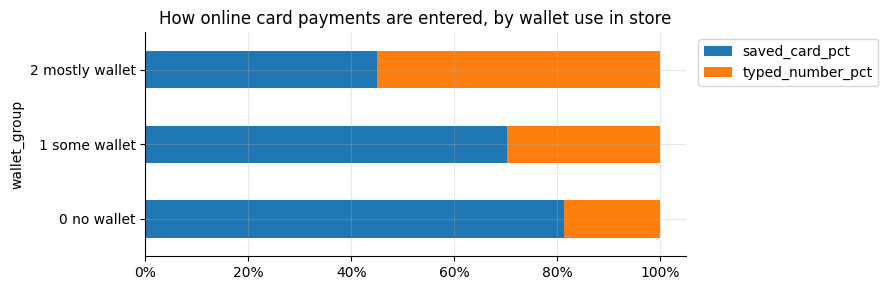

In [11]:
chan = safe(con.sql('''
    SELECT CASE WHEN n_wallet_store = 0 THEN '0 no wallet'
                WHEN wallet_share < 0.5 THEN '1 some wallet'
                ELSE '2 mostly wallet' END AS wallet_group,
           count(*) AS cards,
           100 * sum(n_online_cof) / sum(n_online) AS saved_card_pct,
           100 * sum(n_online_manual) / sum(n_online) AS typed_number_pct,
           100 * sum(n_online_mobile) / sum(n_online) AS via_phone_pct
    FROM active WHERE n_online > 0 GROUP BY 1 ORDER BY 1
''').df())

ax = chan.set_index("wallet_group")[["saved_card_pct", "typed_number_pct"]].plot.barh(stacked=True, figsize=(9, 3))
ax.xaxis.set_major_formatter(pct)
ax.set_title("How online card payments are entered, by wallet use in store")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
chan

In [12]:
# Where does the typing happen? Online payments by channel x entry mode, per wallet group
typing = con.sql(f'''
    SELECT CASE WHEN a.n_wallet_store = 0 THEN '0 no wallet'
                WHEN a.wallet_share < 0.5 THEN '1 some wallet'
                ELSE '2 mostly wallet' END AS wallet_group,
           CASE WHEN t.channel_flg = 'mobile' THEN 'on phone' ELSE 'other device' END AS device,
           t.entry_mode,
           count(DISTINCT t.card) AS cards,
           count(*) AS tx
    FROM read_parquet('{SLIM.as_posix()}/*/*.parquet') t
    JOIN active a USING (card)
    WHERE {IS_ONLINE} AND t.entry_mode IN ('COF', 'Manual key entry')
    GROUP BY ALL
''').df()
typing = safe(typing)
typing["share_of_group_pct"] = typing.tx / typing.groupby("wallet_group").tx.transform("sum") * 100
typing.pivot_table(index="wallet_group", columns=["device", "entry_mode"], values="share_of_group_pct").round(1)

device          on phone                  other device                 
entry_mode           COF Manual key entry          COF Manual key entry
wallet_group                                                           
0 no wallet         49.0              3.2         32.4             15.4
1 some wallet       43.2             17.8         27.0             12.0
2 mostly wallet     30.4             49.4         14.6              5.6

## 5. Stickiness: does a one-click first purchase keep people online?

Cohort cards whose **first online purchase** happened Apr-Dec 2025 (so 6 following months are observable).
Retention = online purchases in at least 3 of the next 6 months. Compared within activity quintiles.

,activity_q,first_payment,cards,retained_pct,never_again_pct
0,1,one-click (saved card),6051,35.7,31.4
1,1,typed card number,7524,22.2,43.2
2,2,one-click (saved card),6249,41.7,27.1
3,2,typed card number,7326,28.8,38.2
4,3,one-click (saved card),6386,46.1,24.3
5,3,typed card number,7189,32.4,37.0
6,4,one-click (saved card),6432,49.0,22.8
7,4,typed card number,7143,34.6,34.1
8,5,one-click (saved card),6728,50.5,22.2
9,5,typed card number,6847,36.8,34.1


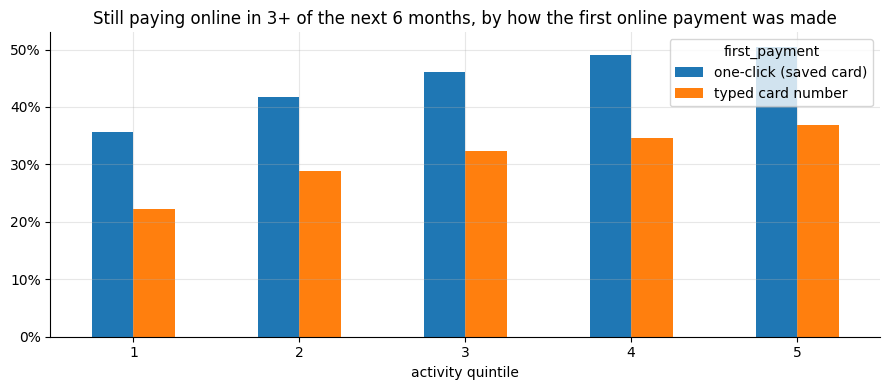

In [13]:
stick = safe(con.sql('''
    WITH firsts AS (
        SELECT c.card, c.first_online_m, f.first_mode, f.first_channel,
               coalesce(c.first_wallet_m <= c.first_online_m, FALSE) AS wallet_user,
               ntile(5) OVER (ORDER BY c.n_tx / c.months_active) AS activity_q
        FROM cohort c JOIN first_online f USING (card)
        WHERE c.first_online_m BETWEEN 3 AND 11
          AND f.first_mode IN ('COF', 'Manual key entry')
    ),
    later AS (
        SELECT f.card, count(*) FILTER (WHERE p.n_online > 0) AS later_online_months
        FROM firsts f LEFT JOIN panel p
          ON p.card = f.card AND p.m BETWEEN f.first_online_m + 1 AND f.first_online_m + 6
        GROUP BY 1
    )
    SELECT activity_q,
           CASE first_mode WHEN 'COF' THEN 'one-click (saved card)' ELSE 'typed card number' END AS first_payment,
           count(*) AS cards,
           100 * avg((later_online_months >= 3)::INT) AS retained_pct,
           100 * avg((later_online_months = 0)::INT) AS never_again_pct
    FROM firsts JOIN later USING (card)
    GROUP BY ALL ORDER BY ALL
''').df())

s = stick.pivot(index="activity_q", columns="first_payment", values="retained_pct")
ax = s.plot.bar(rot=0, figsize=(9, 4))
ax.set_title("Still paying online in 3+ of the next 6 months, by how the first online payment was made")
ax.set_xlabel("activity quintile")
ax.yaxis.set_major_formatter(pct)
plt.tight_layout()
stick

In [14]:
overall = stick.assign(ret=stick.retained_pct * stick.cards, nev=stick.never_again_pct * stick.cards)
overall = overall.groupby("first_payment")[["cards", "ret", "nev"]].sum()
overall["retained_pct"] = overall.ret / overall.cards
overall["never_again_pct"] = overall.nev / overall.cards
overall[["cards", "retained_pct", "never_again_pct"]]

,cards,retained_pct,never_again_pct
first_payment,,,
one-click (saved card),31846,44.8,25.4
typed card number,36029,30.8,37.4


The comparison above could be driven by *what* was bought: subscriptions are both one-click by nature and
recurring. Below the same comparison is made **within the same first-purchase category**.

weighted average difference within category: 3.9 pp (12 of 19 categories positive)


,category,cards_one_click,cards_typed,retained_one_click_pct,retained_typed_pct,diff_pp
149,ELECTRONICS STORES,1567,500,69.9,24.4,45.5
85,TELECOMMUNICATION SERVICES,495,976,59.2,45.0,14.2
7,TOLLS AND BRIDGE FEES,435,807,28.5,18.2,10.3
154,DIGITAL GOODS GAMES,2287,746,39.9,32.4,7.5
5,COMPUTER SOFTWARE STORES,842,605,41.8,35.9,5.9
151,DEPARTMENT STORES,310,617,31.9,27.1,4.9
162,ADVERTISING SERVICES,296,268,38.5,35.1,3.4
148,LOCAL COMMUTER TRANSPORT,211,857,35.1,31.7,3.3
216,"CABLE, SAT, PAY TV/RADIO SVCS",3802,2183,66.1,63.0,3.1
147,TRAVEL AGENCIES,783,2299,17.1,15.0,2.2


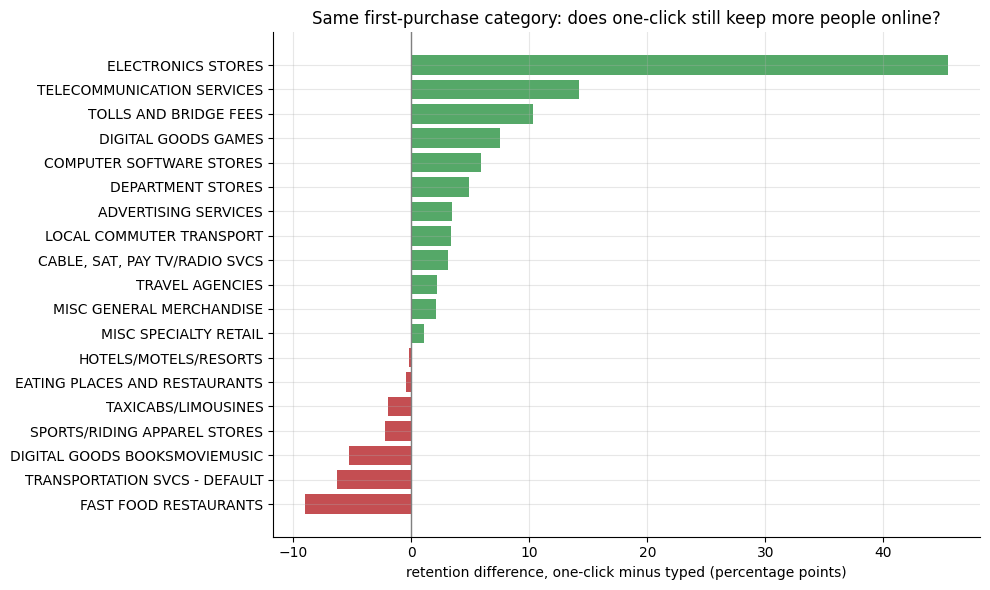

In [15]:
by_cat = con.sql('''
    WITH firsts AS (
        SELECT c.card, c.first_online_m, f.first_mode, f.first_cat
        FROM cohort c JOIN first_online f USING (card)
        WHERE c.first_online_m BETWEEN 3 AND 11
          AND f.first_mode IN ('COF', 'Manual key entry')
    ),
    later AS (
        SELECT f.card, count(*) FILTER (WHERE p.n_online > 0) AS later_online_months
        FROM firsts f LEFT JOIN panel p
          ON p.card = f.card AND p.m BETWEEN f.first_online_m + 1 AND f.first_online_m + 6
        GROUP BY 1
    )
    SELECT first_cat AS category,
           count(*) FILTER (WHERE first_mode = 'COF') AS cards_one_click,
           count(*) FILTER (WHERE first_mode <> 'COF') AS cards_typed,
           100 * avg((later_online_months >= 3)::INT) FILTER (WHERE first_mode = 'COF') AS retained_one_click_pct,
           100 * avg((later_online_months >= 3)::INT) FILTER (WHERE first_mode <> 'COF') AS retained_typed_pct
    FROM firsts JOIN later USING (card)
    GROUP BY 1
''').df()
by_cat = by_cat[by_cat.category.isin(OK_CATS)]  # only categories that pass the 3/75 rule
by_cat = by_cat[(by_cat.cards_one_click >= 200) & (by_cat.cards_typed >= 200)].copy()
by_cat["diff_pp"] = by_cat.retained_one_click_pct - by_cat.retained_typed_pct
by_cat = by_cat.sort_values("diff_pp")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(by_cat.category, by_cat.diff_pp, color=["#55a868" if d > 0 else "#c44e52" for d in by_cat.diff_pp])
ax.axvline(0, color="grey", lw=1)
ax.set_xlabel("retention difference, one-click minus typed (percentage points)")
ax.set_title("Same first-purchase category: does one-click still keep more people online?")
plt.tight_layout()
w = by_cat.cards_one_click + by_cat.cards_typed
print(f"weighted average difference within category: {(by_cat.diff_pp * w).sum() / w.sum():.1f} pp "
      f"({(by_cat.diff_pp > 0).sum()} of {len(by_cat)} categories positive)")
by_cat.sort_values("diff_pp", ascending=False)

## 6. Gateway: what is the first thing people buy online?

,category,cards,wallet_users_pct,one_click_pct,polish_merchant_pct,share_pct
0,"CABLE, SAT, PAY TV/RADIO SVCS",7683,23.7,62.1,15.1,9.0
1,DIGITAL GOODS BOOKSMOVIEMUSIC,6038,31.7,81.2,8.7,7.1
2,TAXICABS/LIMOUSINES,5194,45.1,67.3,53.9,6.1
5,DIGITAL GOODS GAMES,4043,31.5,77.4,0.3,4.7
6,TRAVEL AGENCIES,3780,19.9,24.5,10.6,4.4
8,ELECTRONICS STORES,2875,18.9,77.5,89.8,3.4
9,MISC GENERAL MERCHANDISE,2013,27.4,43.3,6.8,2.4
10,COMPUTER SOFTWARE STORES,1978,25.2,54.9,11.6,2.3
11,HOTELS/MOTELS/RESORTS,1910,23.5,23.0,36.8,2.2
12,TELECOMMUNICATION SERVICES,1851,39.3,33.9,80.1,2.2


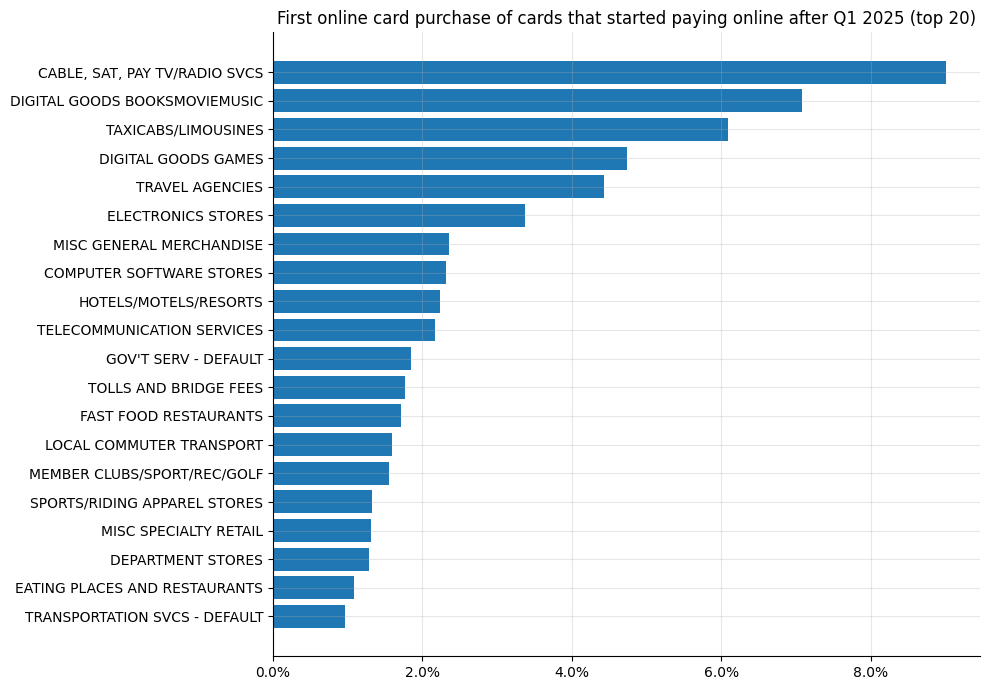

In [16]:
gate = safe(con.sql('''
    SELECT f.first_cat AS category,
           count(*) AS cards,
           100 * avg(coalesce(c.first_wallet_m <= c.first_online_m, FALSE)::INT) AS wallet_users_pct,
           100 * avg((f.first_mode = 'COF')::INT) AS one_click_pct,
           100 * avg(f.first_domestic::INT) AS polish_merchant_pct
    FROM cohort c JOIN first_online f USING (card)
    WHERE c.first_online_m >= 3
    GROUP BY 1 ORDER BY cards DESC
''').df())
gate["share_pct"] = gate.cards / gate.cards.sum() * 100  # share of all starters
gate = gate[gate.category.isin(OK_CATS)].head(20)  # only categories that pass the 3/75 rule

fig, ax = plt.subplots(figsize=(10, 7))
g = gate.sort_values("share_pct")
ax.barh(g.category, g.share_pct)
ax.xaxis.set_major_formatter(pct)
ax.set_title("First online card purchase of cards that started paying online after Q1 2025 (top 20)")
plt.tight_layout()
gate

## 7. Target segment: "ready but not converted"

Active cards that pay **mostly by phone in store (50%+)** but **never paid online by card**.
They already have the card in a digital wallet; the online step is one click away.

In [17]:
seg = con.sql('''
    SELECT count(*) FILTER (WHERE n_online = 0) AS never_online,
           count(*) FILTER (WHERE n_online = 0 AND wallet_share >= 0.5) AS ready_not_converted,
           count(*) AS active_cards
    FROM active
''').df()
seg["ready_share_of_never_pct"] = seg.ready_not_converted / seg.never_online * 100
seg

,never_online,ready_not_converted,active_cards,ready_share_of_never_pct
0,274966,23029,759147,8.4


In [18]:
by_type = safe(con.sql('''
    SELECT card_type, count(*) AS cards,
           100 * avg((n_online = 0)::INT) AS never_online_pct,
           100 * avg((n_online = 0 AND wallet_share >= 0.5)::INT) AS ready_not_converted_pct
    FROM active GROUP BY 1 ORDER BY cards DESC
''').df())
by_type

,card_type,cards,never_online_pct,ready_not_converted_pct
0,CLASSIC,680730,37.3,2.9
1,INFINITE,35042,9.9,5.4
2,BUSINESS,29685,47.5,3.4
3,PREMIER,7644,32.4,4.0
4,PLATINUM,5928,20.3,2.8
5,CORPORATE T&E CARD,62,8.1,0.0
6,VISA SIGNATURE CARD,56,37.5,5.4


,home_area,cards,ready_cards,never_online_pct,ready_pct
12,WARSZAWA,103658,2924,27.8,2.8
42,KATOWICE,62812,2483,40.3,4.0
2,KRAKOW,45979,1295,28.9,2.8
47,POZNAN,39427,1147,32.0,2.9
44,GDANSK,37087,1016,28.3,2.7
50,WROCLAW,35740,1008,29.4,2.8
11,LODZ,24666,756,36.7,3.1
0,RZESZOW,16302,521,40.1,3.2
37,BIELSKO-BIALA,14272,506,41.6,3.5
32,OPOLE,14082,493,42.2,3.5


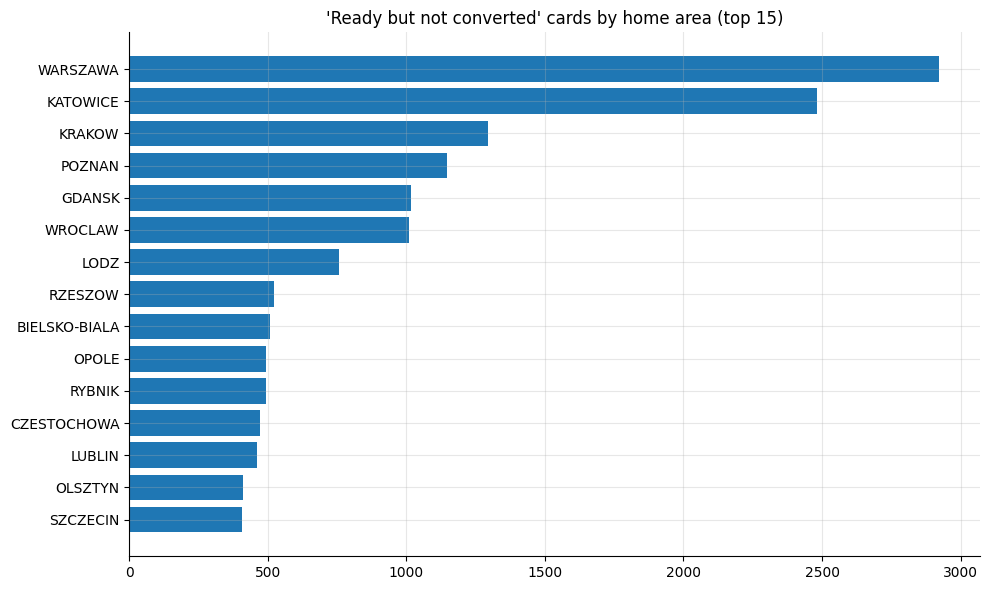

In [19]:
# Where do they live (home FUA assigned to the card)? Top areas by size of the ready segment
by_area = safe(con.sql('''
    SELECT coalesce(home_fua, '(unknown)') AS home_area,
           count(*) AS cards,
           count(*) FILTER (WHERE n_online = 0 AND wallet_share >= 0.5) AS ready_cards,
           100 * avg((n_online = 0)::INT) AS never_online_pct,
           100 * avg((n_online = 0 AND wallet_share >= 0.5)::INT) AS ready_pct
    FROM active GROUP BY 1
''').df())
by_area = by_area[by_area.ready_cards >= MIN_CARDS].sort_values("ready_cards", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
top = by_area.head(15).sort_values("ready_cards")
ax.barh(top.home_area, top.ready_cards)
ax.set_title("'Ready but not converted' cards by home area (top 15)")
plt.tight_layout()
by_area.head(15)

## Takeaways (full data, Polish cards, 759k active cards)

- **Gap:** 36% of active cards never paid online by card in 18 months (21% occasionally, 43% regularly).
- **Readiness:** cards that pay mostly by phone in store paid online in 85-96% of cases vs 41-54% for no-wallet cards, **within every activity quintile**, so it is not just "more active cards".
- **Sequence:** in the cohort with no online payments in Q1 2025, cards already using a phone in store start paying online at 6-7% per month vs 1.5-2% (about 4x, in every quintile). Within 3 months after the first phone payment in store, 18.8% start online vs 4.0% of never-wallet cards in the same months. But among cards that adopted both, online came first slightly more often (47% vs 38%), so the wallet is a **marker of readiness**, not proven to be the trigger.
- **Friction:** phone-first users type the card number much more: for "mostly wallet" cards, 49% of online card payments are **typed card numbers on a phone** (3% for no-wallet cards). They have the card in the wallet already, yet type it into a small screen.
- **Stickiness:** first online payment one-click: 44.8% keep paying online (3+ of the next 6 months) vs 30.8% after typing the number; 25% vs 37% never pay online again. Consistent in every quintile. **Within the same first-purchase category** the gap shrinks to +3.9 pp on average (12 of 19 categories positive; e.g. electronics +45 pp, telecom +14 pp, tolls +10 pp; only categories that pass the 3/75 rule), so part of the headline difference comes from what was bought (subscriptions).
- **Gateway:** first online purchases are mostly digital: pay TV / streaming, digital content, taxi, app stores, games, marketplaces. Most of them go to foreign merchants.
- **Target segment:** 23k active cards (8.4% of never-online cards) pay mostly by phone in store but never online. By card type, INFINITE and VISA SIGNATURE have the highest share (5.4%). By home area the largest groups are Warszawa, Katowice and Kraków; the Katowice area also has a high never-online share (40% vs 28% in Warszawa).

**Limitations:** synthetic data; correlation, not causation; "never online by card" can still mean paying online with BLIK, bank transfer or another card; one person may hold several cards.
